### 랭그래프 구현해보기
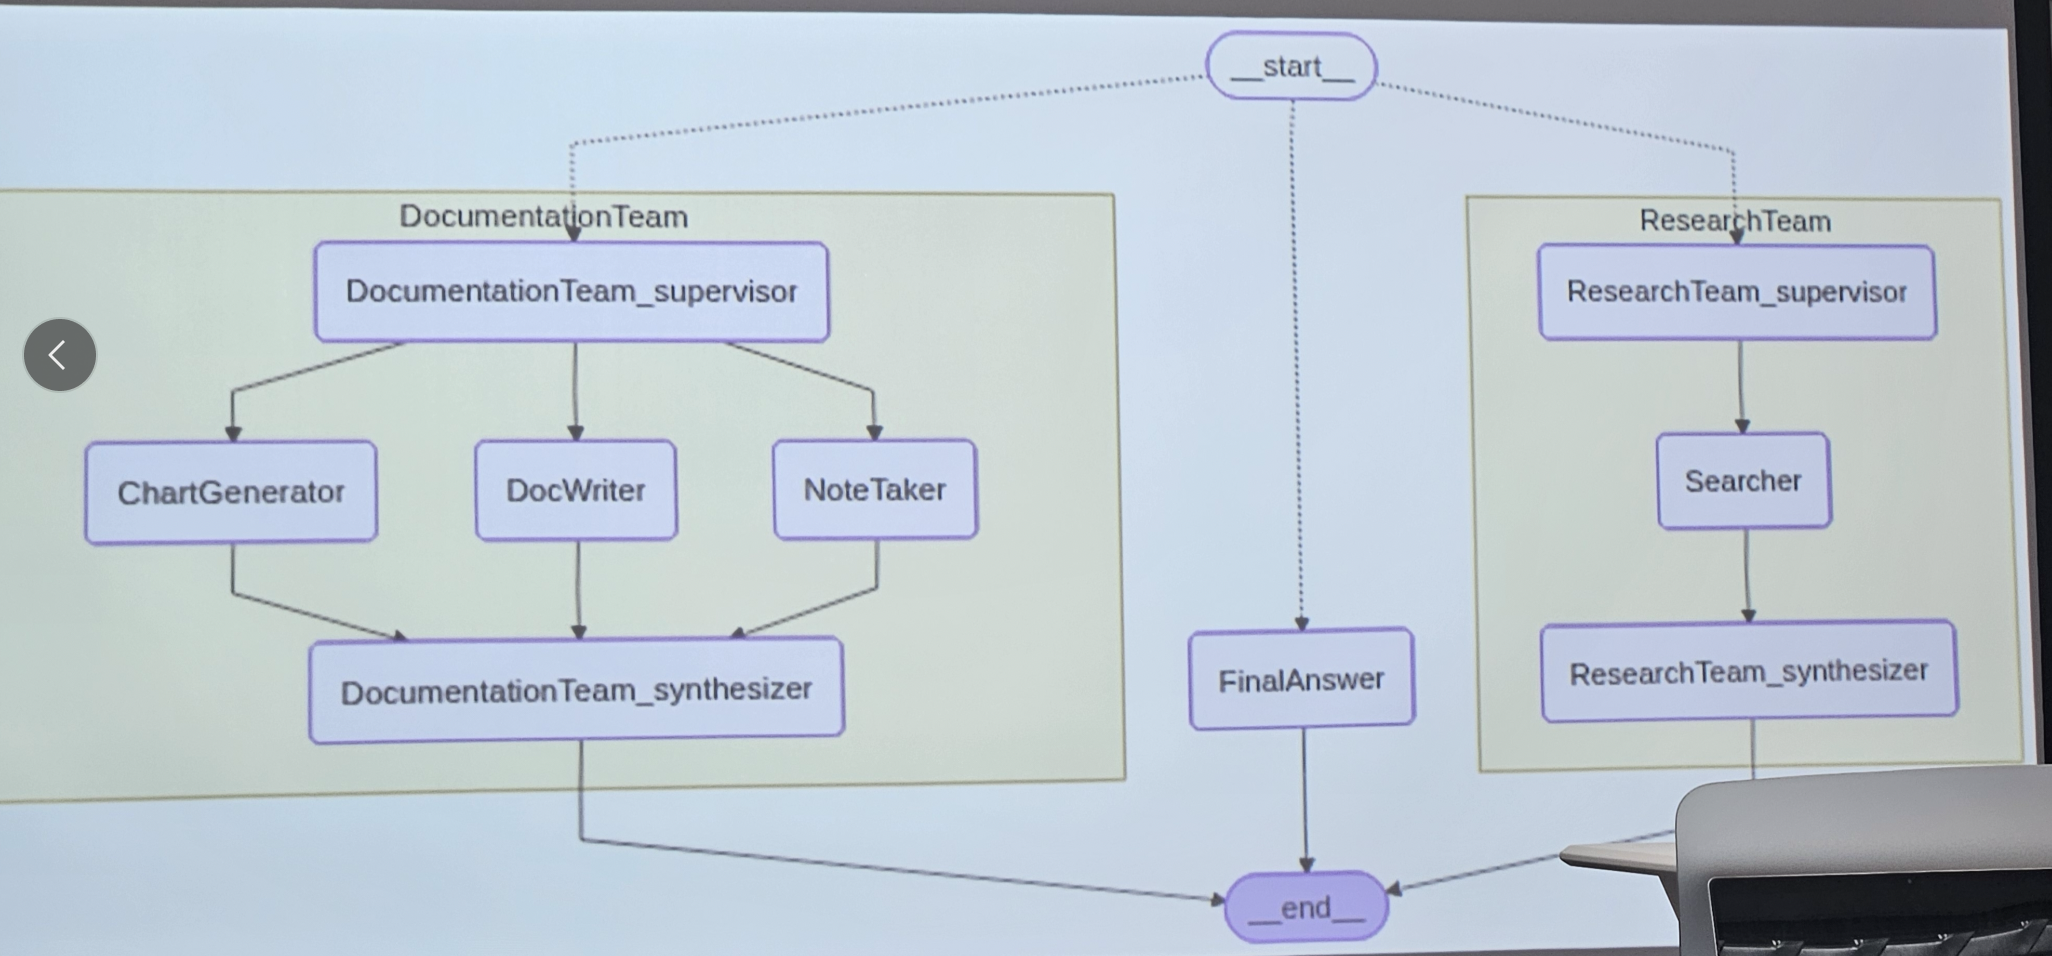

In [ ]:
import os
import json
import asyncio
from typing import TypedDict, List
from dotenv import load_dotenv

from langchain_core.documents import Document
from langchain_core.messages import HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.tools import tool
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_postgres import PGVector
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END


In [ ]:

# DocumentTeamStatus

from pydantic import BaseModel, Field
from datetime import date
from typing import Literal

# 두개의 큰 랭체인 Node 상태값을 관리하기 위한 객체를 정의합니다.
class DocumentTeamStatus(BaseModel):
    doc_name: str = Field(..., min_length=1, max_length=50, description="문서 이름")
    doc_id: int = Field(..., gt=0, description="문서 고유 ID")
    question: str = Field(..., description= "질문내역")
    doc_list: List[Document] = Field(..., description="문서 리스트")
    author: str = Field(..., min_length=1, max_length=30, description="작성자 이름")
    status: Literal["draft", "review", "approved", "archived"] = Field(..., description="문서 상태")
    last_updated: date = Field(..., description="마지막 수정일 (YYYY-MM-DD)")

    
class ResearchTeamStatus(BaseModel):
    project_name: str = Field(..., min_length=1, max_length=100, description="연구 프로젝트 이름")
    team_lead: str = Field(..., min_length=1, max_length=30, description="팀 리더 이름")
    member_count: int = Field(..., ge=1, le=50, description="팀 구성원 수")
    progress: int = Field(..., ge=0, le=100, description="프로젝트 진행률(%)")
    status: Literal["planning", "ongoing", "review", "completed"] = Field(..., description="연구 진행 상태")
    last_updated: date = Field(..., description="마지막 업데이트 날짜 (YYYY-MM-DD)")

# Node 정의
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

def chartGenerator(state: DocumentTeamStatus) -> dict:
    print(" --- chatGenerator 노드 실행 ---")
    question = state['question']
    chart = llm.invoke(question)
    return {"doc_list": chart}

def docWriter(state: DocumentTeamStatus) -> dict:
    print(" --- docwriter 노드 실행 ----")
    
    
    


In [1]:

from langgraph.graph import StateGraph, END

# 1️⃣ 각 노드 정의
def documentation_team(state):
    print("📘 DocumentationTeam working...")
    return {"doc_result": "Document created"}

def research_team(state):
    print("🔍 ResearchTeam researching...")
    return {"research_result": "Research data collected"}

def final_answer(state):
    print("🧩 FinalAnswer synthesizing...")
    return {
        "final_output": f"{state.get('doc_result')} + {state.get('research_result')}"
    }

# 2️⃣ 그래프 구성
workflow = StateGraph()

workflow.add_node("DocumentationTeam", documentation_team)
workflow.add_node("ResearchTeam", research_team)
workflow.add_node("FinalAnswer", final_answer)

workflow.set_entry_point("__start__")

workflow.add_edge("__start__", "DocumentationTeam")
workflow.add_edge("__start__", "ResearchTeam")
workflow.add_edge(["DocumentationTeam", "ResearchTeam"], "FinalAnswer")
workflow.add_edge("FinalAnswer", END)

# 3️⃣ 실행
graph = workflow.compile()
result = graph.invoke({})  # 초기 상태 빈 딕셔너리
print("✅ Result:", result)

TypeError: StateGraph.__init__() missing 1 required positional argument: 'state_schema'